# MMIS 671: Homework 3, Supervised Machine Learning using *ScikitLearn* Classifiers

## Import libraries

In [1]:
import pandas as pd # for data handling
import numpy as np # for computations
import time # to record training and testing time
import matplotlib.pyplot as plt # for plotting

# import metrics to evaluate models
from sklearn.metrics import accuracy_score # accuracy
from sklearn.metrics import confusion_matrix # confusion matrix
from sklearn.metrics import classification_report # precision, recall, f1-score

# scikit-learn classifiers
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression # Logistic Regression
from sklearn.neural_network import MLPClassifier # Neural Network

from sklearn.model_selection import GridSearchCV

## Get data files 

In [2]:
! unzip '/content/drive/My Drive/Colab Notebooks/courses/ML/data/hw3.data.MMIS671.zip'

Archive:  /content/drive/My Drive/Colab Notebooks/courses/ML/data/hw3.data.MMIS671.zip
  inflating: hw3.new.csv             
  inflating: hw3.test.csv            
  inflating: hw3.train.csv           


## Task 0.
Read data from the CSV files “*hw3.train.csv*”, “*hw3.test.csv*”, and “*hw3.new.csv*” into pandas dataframes *train*, *test*, and *new*, respectively. Confirm that the dataframes contain the correct number of rows and columns.

Report the class distribution of ‘y’ in train and test by specifying the proportion of examples in each class. Round the proportions to 4 decimal places. 


### Read data into dataframes

In [3]:
# Read data into pandas dataframes
train = pd.read_csv('hw3.train.csv')
test = pd.read_csv('hw3.test.csv')
new = pd.read_csv('hw3.new.csv')

features = list(train)[1:]
print("Training: %d rows, %d columns" %train.shape)
print("Test: %d rows, %d columns" %test.shape)
print("Unlabeled: %d rows, %d columns" %new.shape)
print("Number of features = %d" %len(features))

Training: 50000 rows, 51 columns
Test: 10000 rows, 51 columns
Unlabeled: 100 rows, 51 columns
Number of features = 50


### Class distribution of *y*

In [4]:
dist_y = pd.DataFrame() # dataframe with class distribution of y
dist_y['y'] = [0, 1, 2] # values of y
dist_y['Proportion in train'] = train.y.value_counts(normalize=True, sort=False)
dist_y['Proportion in test'] = test.y.value_counts(normalize=True, sort=False)
dist_y.to_csv('dist_y.csv', index=False) # save results
dist_y.round(4) # display results

,y,Proportion in train,Proportion in test
0,0,0.2506,0.2491
1,1,0.3914,0.3840
2,2,0.3580,0.3669


## Task 1.
Train ScikitLearn classifiers (with default parameters) using the 50,000 labeled examples in train. Report the time it takes to train the model. 

Predict ‘*y*’ for the  10,000 examples in test using the trained classifier. Report the time it takes to predict the 10,000 test examples.

Report the classification accuracy of your trained model for the 10,000 test examples.  

Classifiers:

- GaussianNB
- DecisionTreeClassifier
- RandomForestClassifier
- KNeighborsClassifier
- SVC
- LogisticRegression
- MLPClassifier





### Specify classifiers
We shall create a dictionary called *classifiers* to contain  classifiers with default parameters. 

In [5]:
classifiers = {'NB': GaussianNB(),
               'DT': DecisionTreeClassifier(),
               'RF': RandomForestClassifier(),
               'KNN': KNeighborsClassifier(),
               'SVC': SVC(),
               'LR': LogisticRegression(),
               'MLP': MLPClassifier()} # dictionary with classifiers 

### Train and evaluate classifiers 

In [6]:
results = [] # list with results

for c in classifiers: # for each classifier
    print("Classifier", c) # classifier being used
    clf = classifiers[c] # create classifier
    print(clf) # show hyper-parameters for classifier
    
    # train classifier 
    st = time.time() # start time for training
    clf.fit(train[features], train.y) # train model
    train_time = time.time() - st # training time
    print("Training time = %4.3f seconds" %train_time)
    
    # predict test cases using trained classifier
    st = time.time() # start time for prediction
    pred = clf.predict(test[features]) # predict y using trained model
    pred_time = time.time() - st # training time
    print("Prediction time = %4.3f seconds" %pred_time)

    # Compute prediction accuracy on test examples
    acc = accuracy_score(test.y, pred) # compute accuracy
    print("Accuracy on test examples = %4.4f" %acc)

    # record results for classifier
    results.append([c, acc, train_time, pred_time])

    print(80*"=" + '\n')

# Results summary
cols = ['Classifier', 'Accuracy', 'Training_time', 'Prediction_time'] # column headers for results
task1_df = pd.DataFrame(results, columns=cols) # dataframe with results
task1_df.to_csv('task1_results.csv', index=False) # save results
task1_df # display results

Classifier NB
GaussianNB(priors=None, var_smoothing=1e-09)
Training time = 0.077 seconds
Prediction time = 0.012 seconds
Accuracy on test examples = 0.8908

Classifier DT
DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')
Training time = 9.554 seconds
Prediction time = 0.008 seconds
Accuracy on test examples = 0.9371

Classifier RF
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
  

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


Training time = 3.940 seconds
Prediction time = 0.008 seconds
Accuracy on test examples = 0.8523

Classifier MLP
MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
              beta_2=0.999, early_stopping=False, epsilon=1e-08,
              hidden_layer_sizes=(100,), learning_rate='constant',
              learning_rate_init=0.001, max_fun=15000, max_iter=200,
              momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,
              power_t=0.5, random_state=None, shuffle=True, solver='adam',
              tol=0.0001, validation_fraction=0.1, verbose=False,
              warm_start=False)


/usr/local/lib/python3.6/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:571: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)


Training time = 214.734 seconds
Prediction time = 0.279 seconds
Accuracy on test examples = 0.9464



,Classifier,Accuracy,Training_time,Prediction_time
0,NB,0.8908,0.076877,0.012220
1,DT,0.9371,9.553571,0.007549
2,RF,0.9747,52.048836,0.254185
3,KNN,0.5930,0.424473,101.861314
4,SVC,0.8994,288.310472,23.218173
5,LR,0.8523,3.940466,0.007719
6,MLP,0.9464,214.734165,0.279274


## Task 2. 
Based on the results on task 1, identify those classifiers that result in a classification accuracy of greater than 0.92 for the test examples. For each such classifier, find a good set of hyper-parameters through 5-fold cross-validation (using only data from train). 

Choose one of these classifiers (with desired hyper-parameters) based on accuracy, training time, prediction time, and interpretability considerations and present the model as your *chosenModel*. Provide a brief rationale for your choice.

Train *chosenModel* using the 50,000 labeled examples from train and use this trained model to predict the output classes for the examples in test. 

Report the classification *accuracy* of *chosenModel* for the 10,000 test examples.

Report the *confusion matrix* for the 10,000 test examples:
	

Report *precision*, *recall*, and *F1-score* (rounded to 4 decimal places) for the 10,000 test examples (using sklearn’s *classification_report*).

### Find good parameter for chosen model

I am going to find a good set of good hyper-parameter values through 5-fold cross-validation using grid search for the DecisionTreeClassifier. You may do the same for other classifiers too. 


In [8]:
parameters = [{'max_leaf_nodes': range(2,10),
               'criterion': ['gini', 'entropy']}] # trees with 2 to 9 leaf nodes 
# define model for grid search
gs = GridSearchCV(DecisionTreeClassifier(),
                  parameters,
                  n_jobs=-1, verbose=1)  # model for grid search

gs.fit(train[features], train.y) # evaluate hyper-parameters

print("\nBest parameters found:")
print(gs.best_params_) # best hyperparameter values

print("\nGrid scores:")
means = gs.cv_results_['mean_test_score'] # mean accuracy with folds
stds = gs.cv_results_['std_test_score'] # standard deviation of accuracies
# for each hyperparameter combination show mean +/- 2 standard-deviations 
for mean, std, params in zip(means, stds, gs.cv_results_['params']):
    print("%0.4f (+/-%0.04f) for %r" %(mean, std * 2, params)) 

Fitting 5 folds for each of 16 candidates, totalling 80 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   18.3s
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:   32.7s finished



Best parameters found:
{'criterion': 'gini', 'max_leaf_nodes': 4}

Grid scores:
0.6276 (+/-0.0027) for {'criterion': 'gini', 'max_leaf_nodes': 2}
0.9103 (+/-0.0066) for {'criterion': 'gini', 'max_leaf_nodes': 3}
0.9721 (+/-0.0029) for {'criterion': 'gini', 'max_leaf_nodes': 4}
0.9720 (+/-0.0028) for {'criterion': 'gini', 'max_leaf_nodes': 5}
0.9720 (+/-0.0027) for {'criterion': 'gini', 'max_leaf_nodes': 6}
0.9720 (+/-0.0029) for {'criterion': 'gini', 'max_leaf_nodes': 7}
0.9720 (+/-0.0027) for {'criterion': 'gini', 'max_leaf_nodes': 8}
0.9719 (+/-0.0028) for {'criterion': 'gini', 'max_leaf_nodes': 9}
0.6276 (+/-0.0027) for {'criterion': 'entropy', 'max_leaf_nodes': 2}
0.9103 (+/-0.0066) for {'criterion': 'entropy', 'max_leaf_nodes': 3}
0.9721 (+/-0.0029) for {'criterion': 'entropy', 'max_leaf_nodes': 4}
0.9721 (+/-0.0029) for {'criterion': 'entropy', 'max_leaf_nodes': 5}
0.9721 (+/-0.0029) for {'criterion': 'entropy', 'max_leaf_nodes': 6}
0.9721 (+/-0.0029) for {'criterion': 'entropy'

### Train *chosenModel*

In [9]:
chosenModel = DecisionTreeClassifier(max_leaf_nodes=4) # chosen model
chosenModel.fit(train[features], train.y)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=4,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

### Evaluate *chosenModel*

In [10]:
pred = chosenModel.predict(test[features]) # predict classes for test examples
print("Accuracy = %4.4f" %accuracy_score(test.y, pred))
print("Classification Report:")
print(classification_report(test.y, pred, digits=4))
print("Confusion matrix")
cm = pd.DataFrame(confusion_matrix(test.y, pred)) # confusion matrix as dataframe
cm.to_csv("DT_conf_matrix.csv")
cm

Accuracy = 0.9747
Classification Report:
              precision    recall  f1-score   support

           0     0.9744    0.9611    0.9677      2491
           1     0.9749    0.9818    0.9783      3840
           2     0.9747    0.9766    0.9756      3669

    accuracy                         0.9747     10000
   macro avg     0.9747    0.9731    0.9739     10000
weighted avg     0.9747    0.9747    0.9747     10000

Confusion matrix


,0,1,2
0,2394,45,52
1,29,3770,41
2,34,52,3583


## Task 3.
Use the trained *chosenModel* to predict the output classes for the 100 unlabeled examples in *new*.


In [11]:
new_pred = pd.DataFrame() # dataframe with predicted classes for unlabeled examples
new_pred['ID'] = new.ID # identifiers for unlabeled examples
new_pred['y'] = chosenModel.predict(new[features]) # predicted labels
new_pred.to_csv('task3_results.csv', index=False) # save results
new_pred # show results

,ID,y
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
95,96,2
96,97,2
97,98,2
98,99,2


## Task 4. 
Write a short memo to the chief data scientist of your organization summarizing any insights that you have drawn about the relationships between the input features and the output *y* based on your analysis.


### Important features

In [12]:
for imp, f in sorted(zip(chosenModel.feature_importances_, features), 
                     reverse=True): # (feature, importance) in descending order
    if imp > 0.005: # mininimum threshhold importance
        print(f, imp)

x45 0.42605719698912364
x20 0.406799264035513
x8 0.16714353897536335


### Infer rules from decision tree

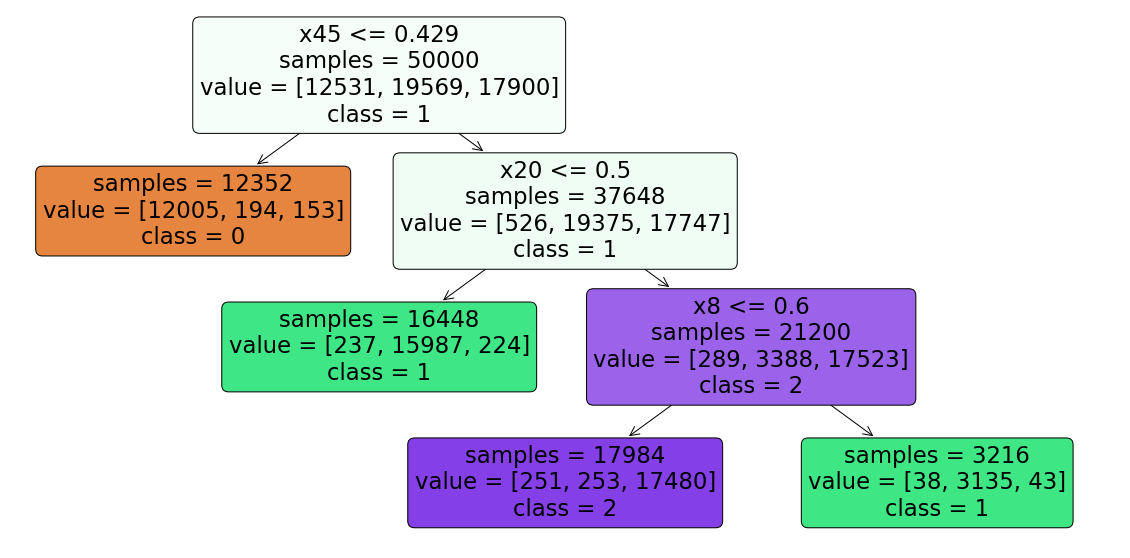

In [13]:
# Display rules
from sklearn.tree import plot_tree # to plot tree
plt.figure(figsize=(20,10)) # figure size
plot_tree(chosenModel, 
          feature_names=features, 
          class_names= [str(c) for c in chosenModel.classes_],
          impurity=False, proportion=False, filled=True, rounded=True)
plt.show()

### Plot feature distribution for classes
Features that have a signicantly different distributions for the classes are likely to be important predictors

Training: distribution of variable by class


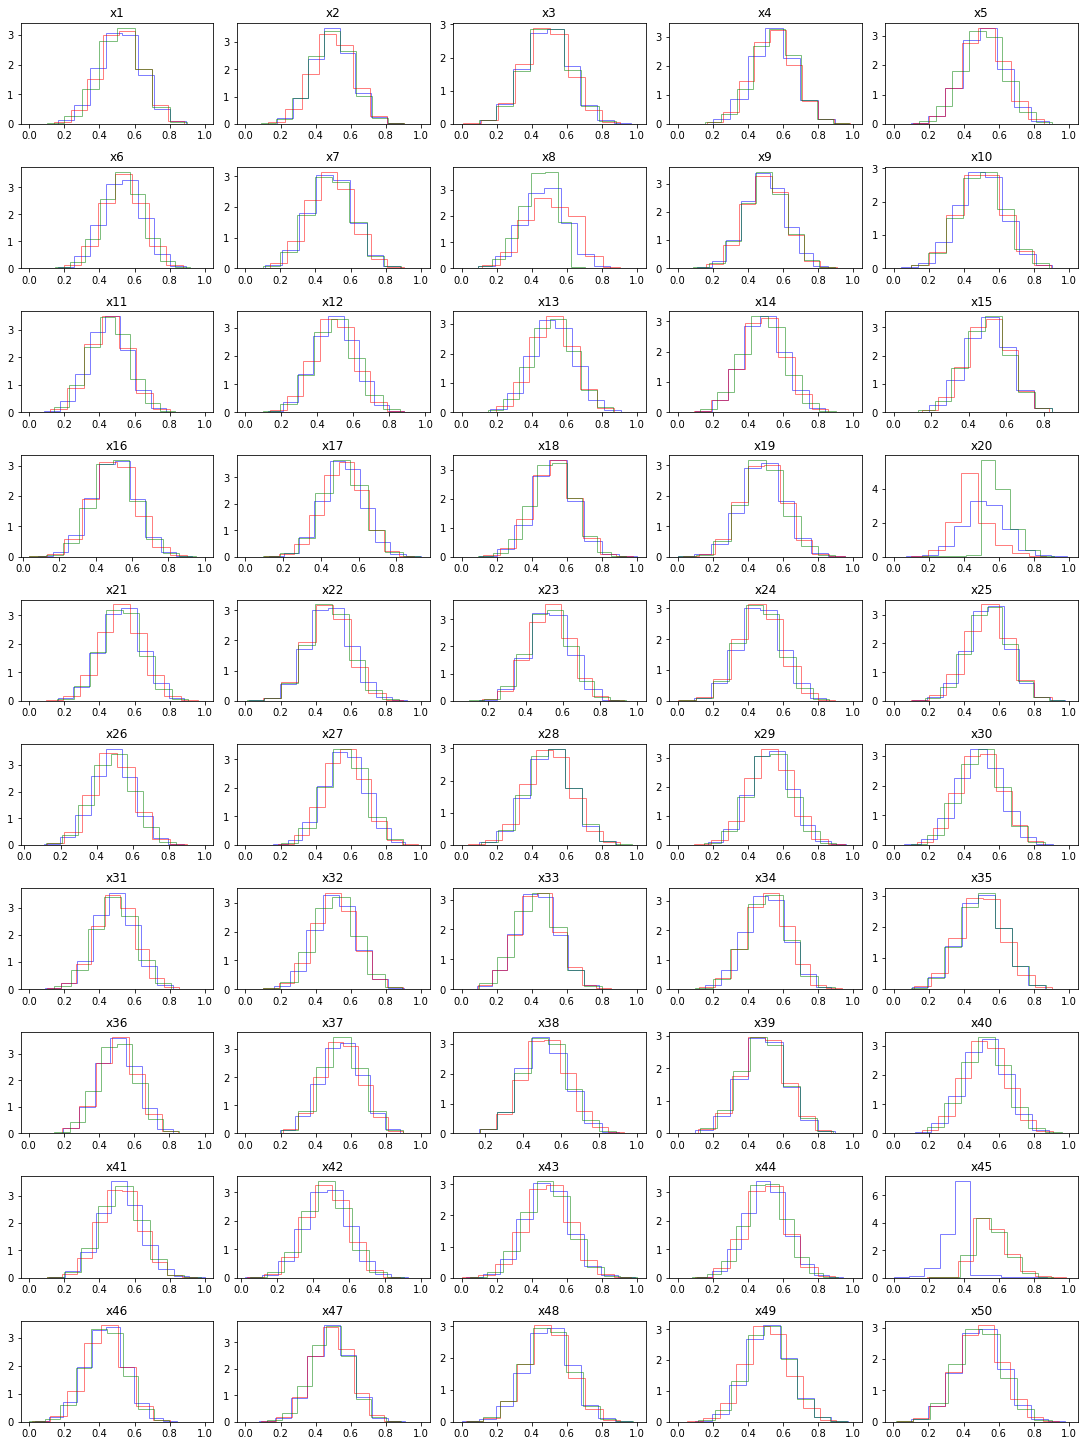

In [14]:
def dist_by_class(df):
    """Function to plot distribution of features by class"""

    def sephist(col, df):
        y0 = df[df['y'] == 0][col]
        y1 = df[df['y'] == 1][col]
        y2 = df[df['y'] == 2][col]
        return y0, y1, y2
    
    plt.figure(figsize=(15,20))
    for num, x in enumerate(features):
        plt.subplot(10, 5, num+1)
        plt.hist(sephist(x, df)[0], bins=10, alpha=0.5, label='y=0', color='b', histtype='step', density=True)
        plt.hist(sephist(x, df)[1], bins=10, alpha=0.5, label='y=1', color='r', histtype='step', density=True)
        plt.hist(sephist(x, df)[2], bins=10, alpha=0.5, label='y=2', color='g', histtype='step', density=True)
        plt.title(x)
    plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

print("Training: distribution of variable by class")
dist_by_class(train)

### Insights into relationships between input features and output *y*
Output y may be reliably predicted using only 3 features: *x45*, *x20*, and *x8*. The following rules may be used for classification:
1. IF   $x45 \le 0.43 $ THEN $y=0$
2. IF   $x45 > 0.43$ AND $x20 \le 0.5$ THEN $y=1$
3. IF   $x45 > 0.43$ AND $x20 > 0.5$ AND $x8 \le 0.6$ THEN $y=2$
3. IF   $x45 > 0.43$ AND $x20 > 0.5$ AND $x8 > 0.6$ THEN $y=1$
